In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/food-image-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/food-image-dataset/Food Classification/momos/208.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/029.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/014.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/275.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/212.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/239.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/150.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/109.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/034.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/149.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/187.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/024.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/033.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/272.jpg
/kaggle/input/food-image-dataset/Food Classification/momos/270

In [1]:
# ============================================
# SECTION 1: SETUP & IMPORTS
# ============================================
# Install required libraries
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow

# Install any missing packages (uncomment if needed on Kaggle)
# !pip install torch torchvision matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import os
import random
import shutil
import time
from PIL import Image

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ No GPU detected! Training will be SLOW. Enable GPU in Kaggle settings.")

# Set device
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.8 GB
Using device: cuda:0


In [2]:
# Define paths
INPUT_DATA_DIR = '/kaggle/input/food-image-dataset/Food Classification'  # Path to your dataset
OUTPUT_DATA_DIR = '/kaggle/working/data'  # Output directory

# Create output directories
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)
TRAIN_DIR = os.path.join(OUTPUT_DATA_DIR, 'train')
VAL_DIR = os.path.join(OUTPUT_DATA_DIR, 'val')
TEST_DIR = os.path.join(OUTPUT_DATA_DIR, 'test')

# Create train, val, test directories
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# Split ratio
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Loop through each class
for class_name in os.listdir(INPUT_DATA_DIR):
    class_dir = os.path.join(INPUT_DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue  # Skip non-directory files

    # Get all image filenames in the class directory
    images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
    random.shuffle(images)  # Shuffle images for randomness

    # Split into train, val, test
    train_images, test_images = train_test_split(images, test_size=(1 - TRAIN_RATIO), random_state=42)
    val_images, test_images = train_test_split(test_images, test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)), random_state=42)

    # Create class directories in train, val, test
    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

    # Copy images to train directory
    for img in train_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(TRAIN_DIR, class_name, img)
        shutil.copy(src, dst)

    # Copy images to val directory
    for img in val_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(VAL_DIR, class_name, img)
        shutil.copy(src, dst)

    # Copy images to test directory
    for img in test_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(TEST_DIR, class_name, img)
        shutil.copy(src, dst)

print("Dataset split into train, val, and test sets successfully!")


Dataset split into train, val, and test sets successfully!


In [3]:
SEED = 42

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")

set_seed(SEED)


Random seed set to: 42


In [4]:
# Paths
DATA_DIR = '/kaggle/working/data'  # Use the split dataset
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001
NUM_WORKERS = 2

print(f"Data directory: {DATA_DIR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")


Data directory: /kaggle/working/data
Batch size: 32
Epochs: 15
Learning rate: 0.001


In [5]:
# Training transforms (WITH augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (NO augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transforms)

# Get class names
classes = train_dataset.classes
num_classes = len(classes)

print(f"Found {len(train_dataset)} training images")
print(f"Found {len(val_dataset)} validation images")
print(f"Found {len(test_dataset)} test images")
print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Found 4378 training images
Found 941 validation images
Found 950 test images
Number of classes: 20
Classes: ['burger', 'butter_naan', 'chai', 'chapati', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa']
Training batches: 137
Validation batches: 30
Test batches: 30


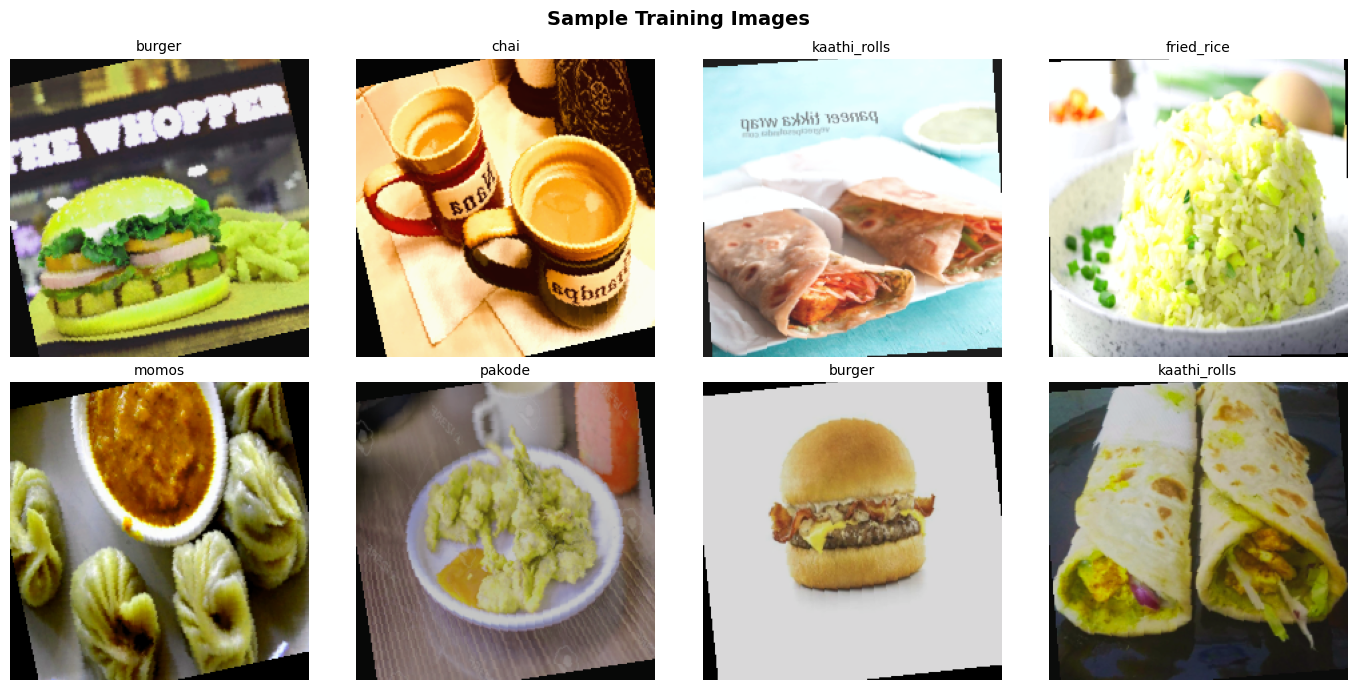

In [6]:
def show_sample_images(dataset, classes, num_images=8):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    indices = np.random.choice(len(dataset), num_images, replace=False)

    for ax, idx in zip(axes, indices):
        image, label = dataset[idx]
        image = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
        ax.imshow(image)
        ax.set_title(classes[label], fontsize=10)
        ax.axis('off')

    plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset, classes)


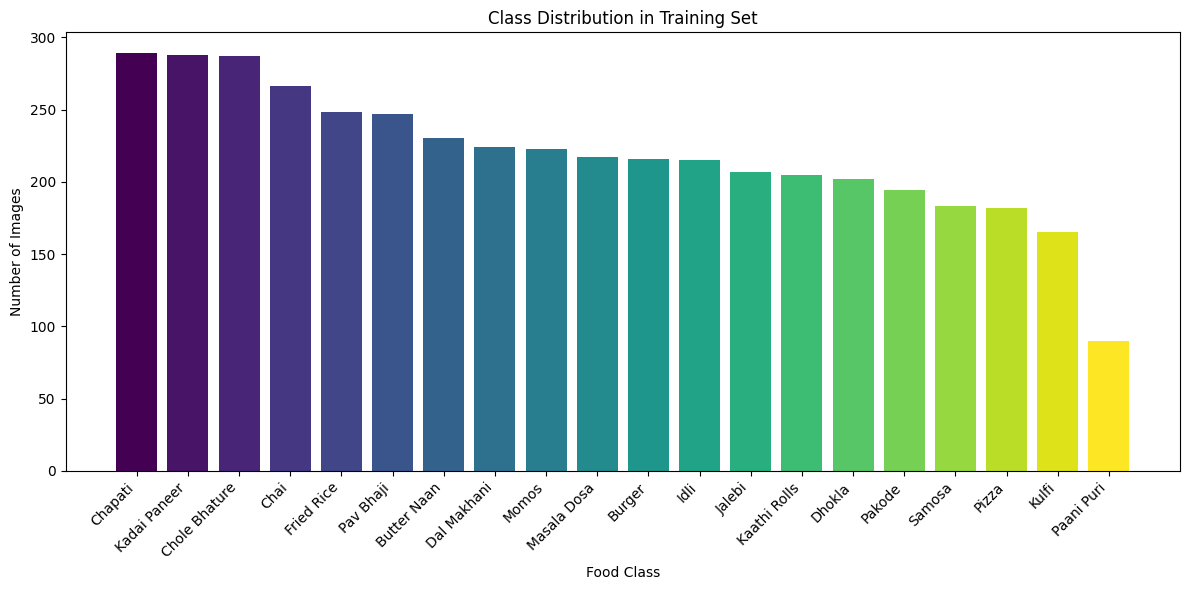

Most images: chapati (289)
Fewest images: paani_puri (90)
Imbalance ratio: 3.21:1
⚠️ Warning: Dataset is imbalanced! Consider using class weights.
Class weights calculated (higher = rarer class)


In [7]:
def plot_class_distribution(dataset, classes):
    class_counts = {}
    for _, label in dataset.samples:
        class_name = classes[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    names, counts = zip(*sorted_classes)

    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    plt.bar(range(len(names)), counts, color=colors)
    plt.xticks(range(len(names)), [n.replace('_', ' ').title() for n in names], rotation=45, ha='right')
    plt.xlabel('Food Class')
    plt.ylabel('Number of Images')
    plt.title('Class Distribution in Training Set')
    plt.tight_layout()
    plt.show()

    max_count = max(counts)
    min_count = min(counts)
    imbalance_ratio = max_count / min_count

    print(f"Most images: {names[0]} ({counts[0]})")
    print(f"Fewest images: {names[-1]} ({counts[-1]})")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

    if imbalance_ratio > 2:
        print("⚠️ Warning: Dataset is imbalanced! Consider using class weights.")

    return class_counts

class_counts = plot_class_distribution(train_dataset, classes)

# Calculate class weights for imbalanced data
total_samples = sum(class_counts.values())
class_weights = torch.tensor([
    total_samples / (num_classes * class_counts[c]) for c in classes
], dtype=torch.float32).to(DEVICE)
print("Class weights calculated (higher = rarer class)")


In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes).to(DEVICE)
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f"Total parameters: {total_params:,}")
print(baseline_model)


Total parameters: 657,428
BaselineCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, ke

In [9]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)
resnet_model = resnet_model.to(DEVICE)
total_params = sum(p.numel() for p in resnet_model.parameters())
print(f"Total parameters: {total_params:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Total parameters: 11,312,980


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, model_name="model"):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0
    patience_counter = 0
    early_stop_patience = 5
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Step the scheduler
        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]['lr']

        epoch_time = time.time() - epoch_start

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.1f}% | "
              f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ✅ New best model! Val Acc: {val_acc*100:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= early_stop_patience:
            print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
            break

    total_time = time.time() - start_time

    # Load best model
    model.load_state_dict(best_model_state)

    print("-" * 60)
    print(f"✅ Training complete!")
    print(f"   Total time: {total_time/60:.1f} minutes")
    print(f"   Best validation accuracy: {best_val_acc*100:.2f}%")

    return history, best_val_acc


In [16]:
baseline_criterion = nn.CrossEntropyLoss(weight=class_weights)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer, mode='max', factor=0.5, patience=2
)

baseline_history, baseline_best_acc = train_model(
    baseline_model,
    train_loader,
    val_loader,
    baseline_criterion,
    baseline_optimizer,
    baseline_scheduler,
    num_epochs=min(EPOCHS, 10),
    device=DEVICE,
    model_name="Baseline CNN"
)


Epoch  1/10 | Train Loss: 2.8675 | Train Acc: 10.1% | Val Loss: 2.7521 | Val Acc: 17.1% | LR: 0.001000 | Time: 77.1s
  ✅ New best model! Val Acc: 17.11%
Epoch  2/10 | Train Loss: 2.6820 | Train Acc: 15.5% | Val Loss: 2.4934 | Val Acc: 18.1% | LR: 0.001000 | Time: 78.9s
  ✅ New best model! Val Acc: 18.07%
Epoch  3/10 | Train Loss: 2.5793 | Train Acc: 18.8% | Val Loss: 2.4210 | Val Acc: 22.4% | LR: 0.001000 | Time: 78.4s
  ✅ New best model! Val Acc: 22.42%
Epoch  4/10 | Train Loss: 2.5433 | Train Acc: 19.9% | Val Loss: 2.4404 | Val Acc: 19.0% | LR: 0.001000 | Time: 78.3s
Epoch  5/10 | Train Loss: 2.4854 | Train Acc: 21.8% | Val Loss: 2.2303 | Val Acc: 26.5% | LR: 0.001000 | Time: 79.2s
  ✅ New best model! Val Acc: 26.46%
Epoch  6/10 | Train Loss: 2.4526 | Train Acc: 22.8% | Val Loss: 2.2774 | Val Acc: 26.7% | LR: 0.001000 | Time: 77.9s
  ✅ New best model! Val Acc: 26.67%
Epoch  7/10 | Train Loss: 2.3923 | Train Acc: 24.7% | Val Loss: 2.2041 | Val Acc: 28.3% | LR: 0.001000 | Time: 76.3s
 

In [17]:
# Phase 1: Freeze backbone, train classifier only
for param in resnet_model.parameters():
    param.requires_grad = False
for param in resnet_model.fc.parameters():
    param.requires_grad = True

resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)
resnet_optimizer = optim.Adam(resnet_model.fc.parameters(), lr=LEARNING_RATE)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='max', factor=0.5, patience=2)

resnet_history_p1, _ = train_model(
    resnet_model, train_loader, val_loader, resnet_criterion, resnet_optimizer, resnet_scheduler,
    num_epochs=5, device=DEVICE, model_name="ResNet-18 (Phase 1)"
)

# Phase 2: Unfreeze and fine-tune
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=1e-4)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='max', factor=0.5, patience=2)

resnet_history_p2, resnet_best_acc = train_model(
    resnet_model, train_loader, val_loader, resnet_criterion, resnet_optimizer, resnet_scheduler,
    num_epochs=EPOCHS, device=DEVICE, model_name="ResNet-18 (Phase 2)"
)

resnet_history = {
    'train_loss': resnet_history_p1['train_loss'] + resnet_history_p2['train_loss'],
    'train_acc': resnet_history_p1['train_acc'] + resnet_history_p2['train_acc'],
    'val_loss': resnet_history_p1['val_loss'] + resnet_history_p2['val_loss'],
    'val_acc': resnet_history_p1['val_acc'] + resnet_history_p2['val_acc'],
}


Epoch  1/5 | Train Loss: 2.2708 | Train Acc: 33.6% | Val Loss: 1.2816 | Val Acc: 68.8% | LR: 0.001000 | Time: 76.0s
  ✅ New best model! Val Acc: 68.76%
Epoch  2/5 | Train Loss: 1.5766 | Train Acc: 53.6% | Val Loss: 1.0726 | Val Acc: 70.1% | LR: 0.001000 | Time: 76.7s
  ✅ New best model! Val Acc: 70.14%
Epoch  3/5 | Train Loss: 1.3963 | Train Acc: 57.7% | Val Loss: 1.0729 | Val Acc: 67.9% | LR: 0.001000 | Time: 77.6s
Epoch  4/5 | Train Loss: 1.3233 | Train Acc: 59.9% | Val Loss: 0.9296 | Val Acc: 74.4% | LR: 0.001000 | Time: 76.8s
  ✅ New best model! Val Acc: 74.39%
Epoch  5/5 | Train Loss: 1.2979 | Train Acc: 60.9% | Val Loss: 0.8783 | Val Acc: 76.4% | LR: 0.001000 | Time: 77.9s
  ✅ New best model! Val Acc: 76.41%
------------------------------------------------------------
✅ Training complete!
   Total time: 6.4 minutes
   Best validation accuracy: 76.41%
Epoch  1/15 | Train Loss: 0.9035 | Train Acc: 72.9% | Val Loss: 0.6126 | Val Acc: 83.6% | LR: 0.000100 | Time: 78.0s
  ✅ New best m

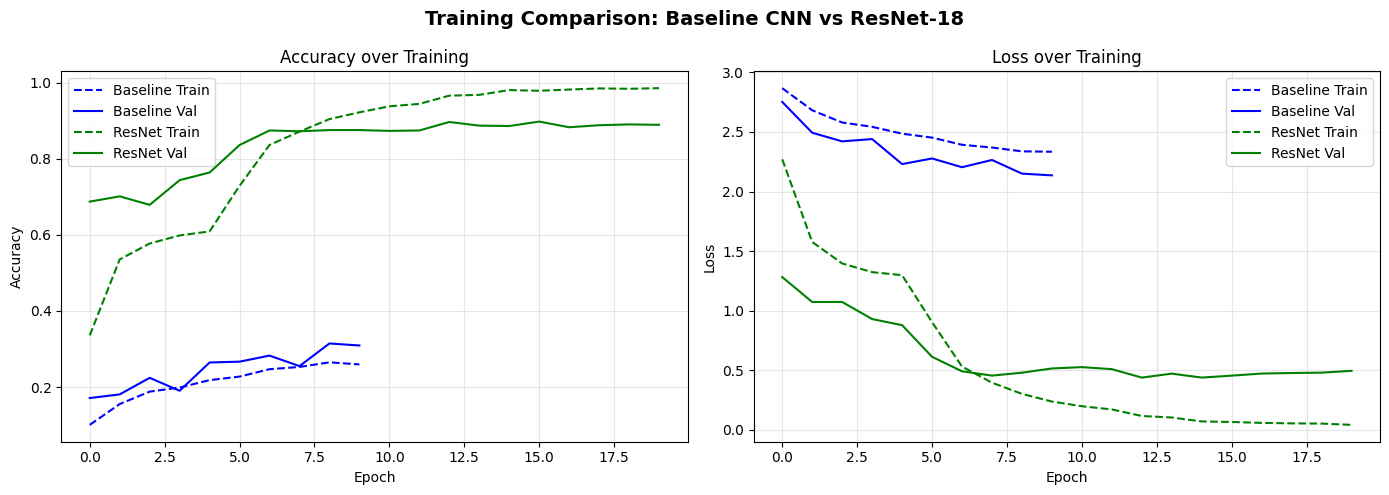

In [18]:
def plot_training_history(baseline_hist, resnet_hist):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(baseline_hist['train_acc'], label='Baseline Train', linestyle='--', color='blue')
    ax.plot(baseline_hist['val_acc'], label='Baseline Val', color='blue')
    ax.plot(resnet_hist['train_acc'], label='ResNet Train', linestyle='--', color='green')
    ax.plot(resnet_hist['val_acc'], label='ResNet Val', color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy over Training')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(baseline_hist['train_loss'], label='Baseline Train', linestyle='--', color='blue')
    ax.plot(baseline_hist['val_loss'], label='Baseline Val', color='blue')
    ax.plot(resnet_hist['train_loss'], label='ResNet Train', linestyle='--', color='green')
    ax.plot(resnet_hist['val_loss'], label='ResNet Val', color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss over Training')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle('Training Comparison: Baseline CNN vs ResNet-18', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(baseline_history, resnet_history)



Baseline CNN Test Results:
Accuracy: 29.26%
Classification Report:
               precision    recall  f1-score   support

       burger       0.18      0.74      0.29        47
  butter_naan       0.50      0.28      0.36        50
         chai       0.53      0.45      0.49        58
      chapati       0.37      0.27      0.31        62
chole_bhature       0.34      0.32      0.33        62
  dal_makhani       0.58      0.14      0.23        49
       dhokla       0.00      0.00      0.00        44
   fried_rice       0.41      0.37      0.39        54
         idli       0.63      0.40      0.49        47
       jalebi       0.30      0.91      0.46        45
 kaathi_rolls       0.13      0.16      0.14        44
 kadai_paneer       0.36      0.31      0.33        62
        kulfi       0.25      0.03      0.05        36
  masala_dosa       0.28      0.32      0.30        47
        momos       0.17      0.02      0.04        48
   paani_puri       0.06      0.05      0.06       

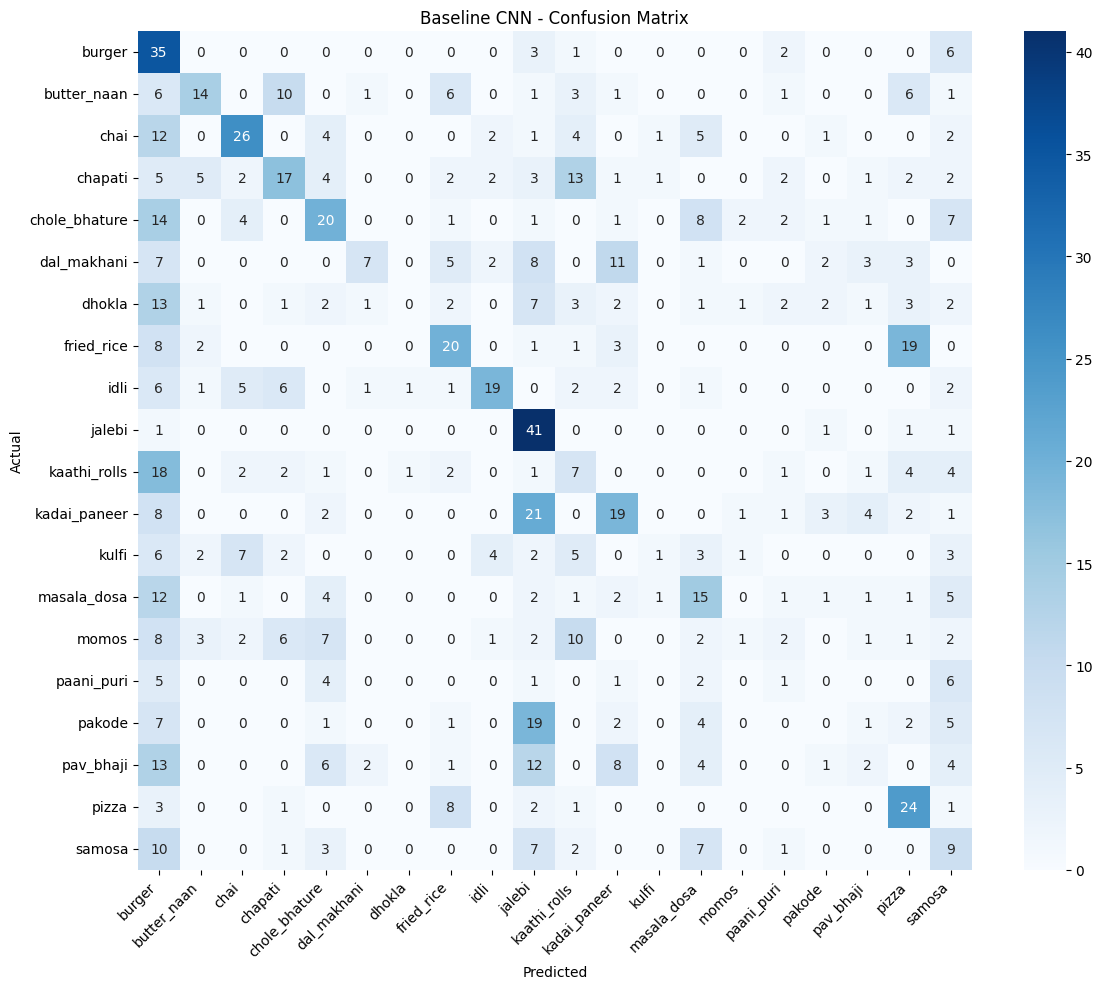


ResNet-18 Test Results:
Accuracy: 87.26%
Classification Report:
               precision    recall  f1-score   support

       burger       0.98      0.98      0.98        47
  butter_naan       0.79      0.76      0.78        50
         chai       0.88      0.90      0.89        58
      chapati       0.79      0.84      0.81        62
chole_bhature       0.88      0.95      0.91        62
  dal_makhani       0.78      0.82      0.80        49
       dhokla       0.93      0.91      0.92        44
   fried_rice       0.93      0.94      0.94        54
         idli       0.88      0.91      0.90        47
       jalebi       0.98      0.96      0.97        45
 kaathi_rolls       0.70      0.75      0.73        44
 kadai_paneer       0.85      0.89      0.87        62
        kulfi       0.89      0.86      0.87        36
  masala_dosa       0.93      0.81      0.86        47
        momos       0.83      0.92      0.87        48
   paani_puri       0.94      0.85      0.89        20

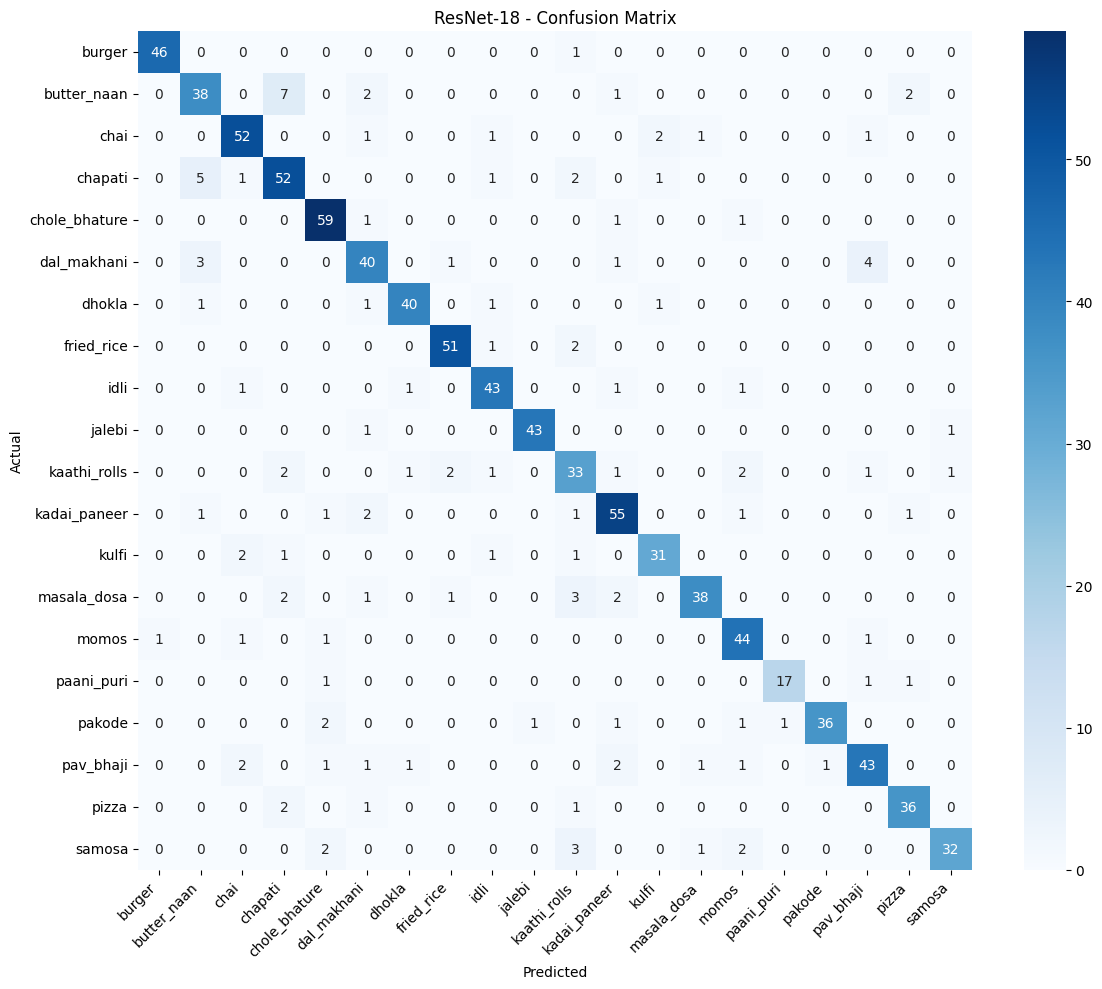

In [19]:
def evaluate_model(model, loader, classes, device, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\n{model_name} Test Results:")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return accuracy, all_preds, all_labels

baseline_test_acc, _, _ = evaluate_model(baseline_model, test_loader, classes, DEVICE, "Baseline CNN")
resnet_test_acc, resnet_preds, resnet_labels = evaluate_model(resnet_model, test_loader, classes, DEVICE, "ResNet-18")


In [21]:
comparison = {
    'Metric': ['Test Accuracy', 'Best Val Accuracy', 'Parameters', 'Training Strategy'],
    'Baseline CNN': [
        f'{baseline_test_acc*100:.2f}%',
        f'{baseline_best_acc*100:.2f}%',
        f'{sum(p.numel() for p in baseline_model.parameters()):,}',
        'From scratch'
    ],
    'ResNet-18': [
        f'{resnet_test_acc*100:.2f}%',
        f'{resnet_best_acc*100:.2f}%',
        f'{sum(p.numel() for p in resnet_model.parameters()):,}',
        'Transfer learning'
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

improvement = (resnet_test_acc - baseline_test_acc) * 100
print(f"ResNet-18 improved accuracy by {improvement:.1f}% over baseline!")


           Metric Baseline CNN         ResNet-18
    Test Accuracy       29.26%            87.26%
Best Val Accuracy       31.46%            89.80%
       Parameters      657,428        11,312,980
Training Strategy From scratch Transfer learning
ResNet-18 improved accuracy by 58.0% over baseline!


In [23]:
save_path = '/kaggle/working/food_classifier_resnet18.pth'

torch.save({
    'model_state_dict': resnet_model.state_dict(),
    'classes': classes,
    'num_classes': num_classes,
    'accuracy': resnet_test_acc
}, save_path)

print(f"Model saved to: {save_path}")


Model saved to: /kaggle/working/food_classifier_resnet18.pth


In [24]:
print(f"""
📊 Results:
   • Baseline CNN: {baseline_test_acc*100:.2f}% accuracy
   • ResNet-18: {resnet_test_acc*100:.2f}% accuracy
   • Improvement: +{improvement:.1f}%

📝 What we learned:
   1. Data augmentation prevents overfitting
   2. Transfer learning is powerful for small datasets
   3. Class weights help with imbalanced data
   4. Learning rate scheduling improves convergence
   5. Early stopping prevents overfitting

🚀 Next steps:
   1. Try other architectures (ResNet-50, EfficientNet)
   2. Add more training data
   3. Deploy the model as a web app
   4. Try test-time augmentation for better accuracy

📁 Files saved:
   • {save_path} - Trained model weights
""")



📊 Results:
   • Baseline CNN: 29.26% accuracy
   • ResNet-18: 87.26% accuracy
   • Improvement: +58.0%

📝 What we learned:
   1. Data augmentation prevents overfitting
   2. Transfer learning is powerful for small datasets
   3. Class weights help with imbalanced data
   4. Learning rate scheduling improves convergence
   5. Early stopping prevents overfitting

🚀 Next steps:
   1. Try other architectures (ResNet-50, EfficientNet)
   2. Add more training data
   3. Deploy the model as a web app
   4. Try test-time augmentation for better accuracy

📁 Files saved:
   • /kaggle/working/food_classifier_resnet18.pth - Trained model weights

